Statistical Hypothesis Testing & Correlation Analysis

T-tests and statistical hypothesis testing using Python.

Datasets:

data_for_ind.csv
data_for_paired.csv
daily_usage.csv

Tools: Python, Pandas, SciPy, Matplotlib

Author: Aida Badenova | nFactorial School

Задача 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [2]:
df = pd.read_csv('data_for_ind.csv')
print(df.head())

   employee_id department  salary
0            1         IT  634769
1            2         IT  590321
2            3         IT  645338
3            4         IT  706612
4            5         IT  583609


In [3]:
print(df.tail())

    employee_id department  salary
95           96         HR  486824
96           97         HR  574806
97           98         HR  573052
98           99         HR  560255
99          100         HR  548270


In [4]:
it = df[df['department'] == 'IT']['salary'] # Разделяем зарплаты IT и HR и находим их среднюю
hr = df[df['department'] == 'HR']['salary']
print ('Средняя зарплата IT:', it.mean())
print ('средняя зарплата HR:', hr.mean())

Средняя зарплата IT: 584216.3
средняя зарплата HR: 560888.58


# H0 (нулевая гипотеза): зарплаты в IT и HR одинаковы
# H1 (альтернативная гипотеза): зарплаты в IT и HR отличаются

In [5]:
stat_it, p_it = stats.shapiro(it) # Проверка нормальности распределения данных. Делаем тест Шапиро-Уилка, если p>0.05 распределение нормальное и дисперсии равны (применяем t-тест Стьюдента)(а если оба нормальные но дисперсии разные то применяем тест Уэлча), а если p<0.05 то распределение не нормальное(то применяем тест Манна-Уитни)
stat_hr, p_hr = stats.shapiro(hr)

print ('Шапиро-Уилк IT: p =', p_it)
print ('Шапиро-Уилк HR: p =', p_hr)

Шапиро-Уилк IT: p = 0.6721961081672885
Шапиро-Уилк HR: p = 0.2616042796564361


In [6]:
stat_lev, p_lev = stats.levene(it,hr) # проверяем равенство дисперсий, одинаковый ли разброс зарплат это тест Левена: p > 0.05 - дсиперсии равны тест Стьдента, а если p < 0.05 - дисперсии разные то применяем тест Уэлча
print ('Тест Левена: p =', p_lev)

Тест Левена: p = 0.010480889337869819


In [7]:
stat, p_value = stats.ttest_ind(it, hr, equal_var = False) # Применяем тест Уэлча 
print ('Тест Уэлча: p =', p_value)

Тест Уэлча: p = 0.03887064645559164


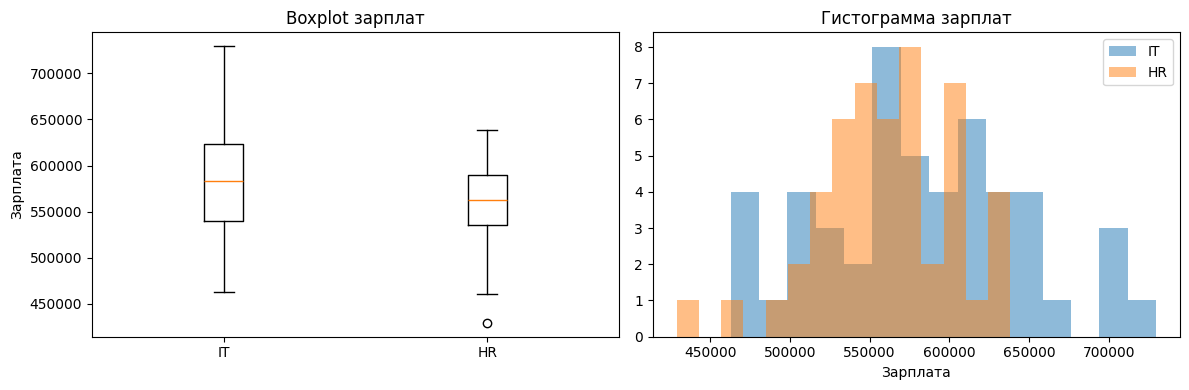

In [8]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# Boxplot
axes[0].boxplot([it,hr], tick_labels = ['IT', 'HR'])
axes[0].set_title ('Boxplot зарплат')
axes[0].set_ylabel ('Зарплата')

# Гистограмма
axes[1].hist (it, bins = 15, alpha = 0.5, label = 'IT')
axes[1].hist (hr, bins = 15, alpha = 0.5, label = 'HR')
axes[1].set_title('Гистограмма зарплат')
axes[1].set_xlabel('Зарплата')
axes[1].legend()

plt.tight_layout()
plt.show()

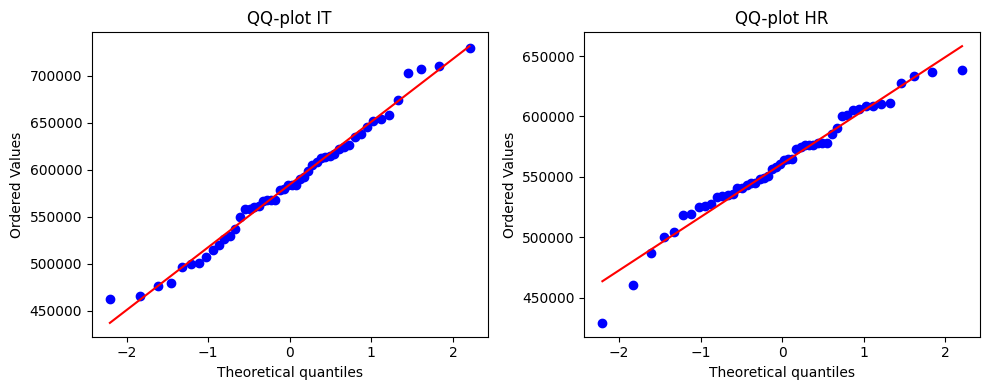

In [9]:
fig, axes = plt.subplots (1, 2, figsize = (10, 4))
stats.probplot(it, plot=axes[0])
axes[0].set_title('QQ-plot IT')
stats.probplot (hr, plot=axes[1])
axes[1].set_title('QQ-plot HR')
plt.tight_layout()
plt.show()


Выводы: 
Шапиро-Уилк: оба распределения нормальные (p>0.05)
Тест Левена: дисперсии разные (p = 0.010 < 0.05)
Применен тест Уэлча (equal_var = False)
p-value = 0.038 < 0.05 значит отвергаем H0
Вывод: зарплаты в IT и HR отличаются по результатам тестов 

Задача 2 

In [10]:
df2 = pd.read_csv('data_for_paired.csv')
print (df2.head())

   student_id  score_before  score_after
0           1            67           72
1           2            75           78
2           3            81           88
3           4            60           65
4           5            59           62


H0: обучение не повлияло - оценки до и после одинаковы
H1: обучение повлияло - оценки после выше чем до

In [11]:
before = df2 ['score_before'] # берем столбцы и считаем разности
after = df2 ['score_after']

diff = after - before
print ('Средняя разность:', diff.mean())

Средняя разность: 4.325


In [12]:
stat, p_shapiro = stats.shapiro(diff) # делаем тест Шапиро-Уилка. Однако p=0.0004 это намного меньше 0.05 значит не нормально распределены. но данные зависимые один и тот же человек до и после.поэтому применяем тест Вилкоксона 
print ('Шапиро-Уилк: p =', p_shapiro)

Шапиро-Уилк: p = 0.0004515044787704953


In [13]:
stat, p_value = stats.wilcoxon(before, after) # Тест Вилкоксона вышел намного меньше 0.05 значит обучение точно повлияло на оценки
print ('Тест Вилкоксона: p =', p_value)

Тест Вилкоксона: p = 1.9649908159950417e-08


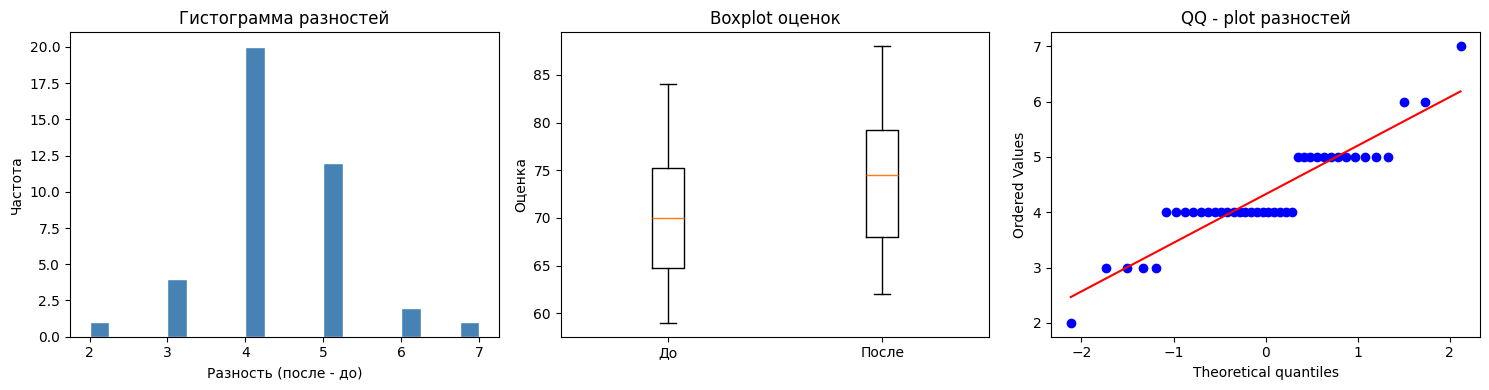

In [14]:
fig, axes = plt.subplots (1, 3, figsize = (15, 4))

# Гистограмма разностей
axes[0].hist(diff, bins = 20, color = 'steelblue', edgecolor = 'white')
axes[0].set_title ('Гистограмма разностей')
axes[0].set_xlabel('Разность (после - до)')
axes[0].set_ylabel('Частота')

# Boxplot
axes[1].boxplot([before, after], tick_labels = ['До', 'После'])
axes[1].set_title ('Boxplot оценок')
axes[1].set_ylabel('Оценка')

# QQ - plot разностей
stats.probplot(diff, plot = axes [2])
axes[2].set_title ('QQ - plot разностей')

plt.tight_layout ()
plt.show()

Выводы: 
Средняя разность: 4.3 балла, оценки выросли после обучения
Шапиро-Уилк: p = 0.0004 < 0.05 - распределение не нормальное 
Применен тест Вилкоксона
p-value = 0.0000000196 < 0.05 значит отвергаем H0
Вывод: обучение значительно улучшило оценки студентов

Задача 3

In [15]:
df3 = pd.read_csv('daily_usage.csv')
print (df3.head())

   minutes_spent
0      15.493428
1      14.223471
2      15.795377
3      17.546060
4      14.031693


In [16]:
print ('Среднее:', df3['minutes_spent'].mean())
print ('Количество:', df3['minutes_spent'].count ())

Среднее: 14.049052189487718
Количество: 50


H0: среднее время = 15 минут (компания права)
H1: среднее время не равно 15 минут (компания ошибается)

In [17]:
stat, p_shapiro = stats.shapiro(df3['minutes_spent']) # делаем тест Шапиро-Уилка. p = 0.67 это больше 0.05 значит распределение нормальное делаем t-тест Стьдента
print ('Шапиро-Уилк: p =', p_shapiro)

Шапиро-Уилк: p = 0.6722075649026826


In [18]:
stat, p_value = stats.ttest_1samp (df3['minutes_spent'], popmean = 15) 

In [19]:
print ('p-value =', p_value)

if p_value < 0.05:
    print ('Отвергаем H0 - среднее отличается от 15 минут')
else:
    print ('Не отвергаем HO - среднее не отличается от 15 минут')

p-value = 0.00073849707211413
Отвергаем H0 - среднее отличается от 15 минут


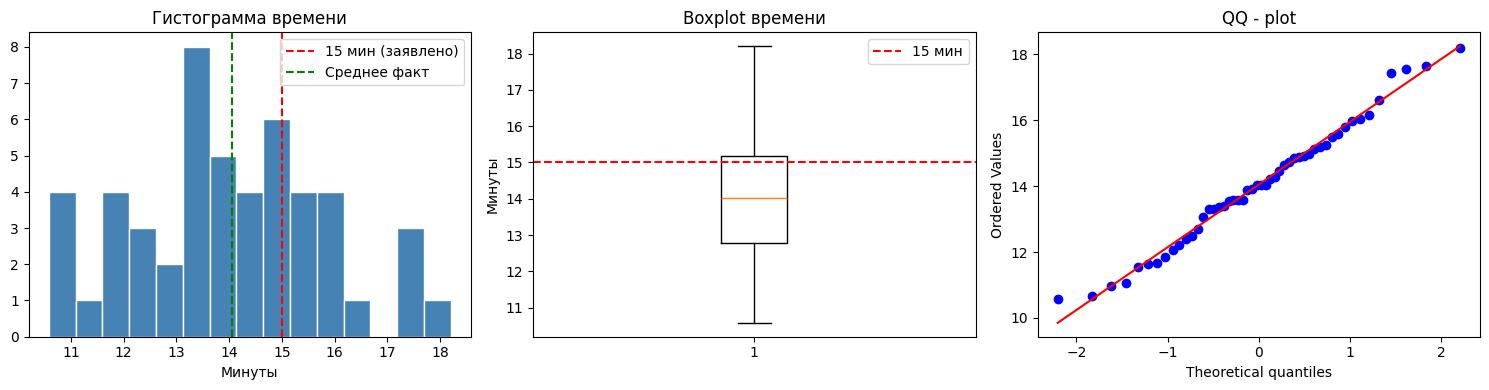

In [20]:
fig, axes = plt.subplots (1, 3, figsize = (15, 4))

#Гистограмма
axes[0].hist(df3['minutes_spent'], bins=15, color = 'steelblue', edgecolor = 'white')
axes[0].axvline(x = 15, color = 'red', linestyle = '--', label = '15 мин (заявлено)')
axes[0].axvline (x = df3['minutes_spent'].mean(),color = 'green', linestyle = '--', label = 'Среднее факт')
axes[0].set_title ('Гистограмма времени')
axes[0].set_xlabel('Минуты')
axes[0].legend()

# Boxplot
axes[1].boxplot(df3['minutes_spent'])
axes[1].axhline(y = 15, color = 'red', linestyle = '--', label = '15 мин')
axes[1].set_title ('Boxplot времени')
axes[1].set_ylabel('Минуты')
axes[1].legend()
# QQ - plot
stats.probplot(df3['minutes_spent'], plot = axes [2])
axes[2].set_title ('QQ - plot')

plt.tight_layout ()
plt.show()

Выводы: 
Среднее фактическое время: 14.05 минут
Компания заявляет 15 минут
Шапиро-Уилк: p = 0.67 > 0.05 - распределение нормальное и применен t-тест Стьюдента
p-value = 0.00073 < 0.05 значит отвергаем H0
Вывод: утверждение компании не подтверждается пользователи проводят меньше на одну минуту
